# MFAA Chapter 5 Laboratory
**Liquidity Shock Simulator** (book §5.9)

Manage an illiquid position through liquidity cycles and funding shocks; watch realizable value diverge from fundamental value; price the divergence with the operator L. Seed `20260500`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch05
from dataclasses import replace

## 1. The reservation value and the discount surface δ*(u, ν) (Proposition 5.5)

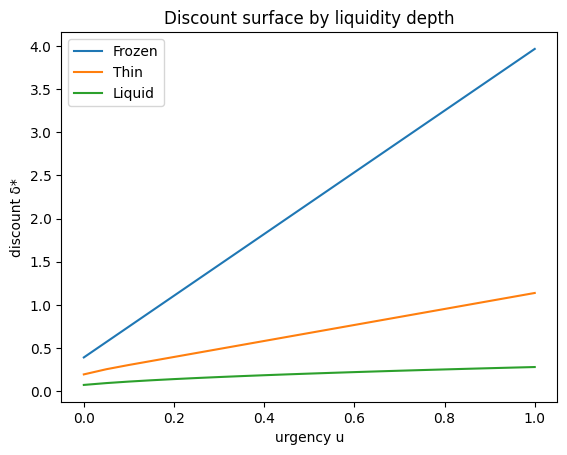

In [2]:
p = ch05.LiquidityParams()
surf = ch05.discount_surface(p)
for st in surf['states']:
    plt.plot(surf['urgency'], surf['discount'][st], label=st)
plt.xlabel('urgency u'); plt.ylabel('discount δ*'); plt.legend(); plt.title('Discount surface by liquidity depth');

Discount rises with urgency (movement along a curve) and falls with depth (jump across curves) — the chapter's quantitative signature.

## 2. E4 / Ex 5.7 — holding-period Mellin transform
Closed forms **0.9346** (θ=1) and **0.9281** (θ=2); variance finite iff ν+2(ρ−g)−σ²>0.

In [3]:
pa = ch05.LiquidityParams(rho=0.10, g=0.03, sigma_V=0.25, V0=1.0)
for th in (1.0, 2.0):
    m = ch05.mellin_transform(th, pa, 1.0)
    print(f'theta={th}: closed form {m["value"]:.4f}, finite={m["finite"]}')
hp = ch05.holding_period_simulation(pa, 1.0)
for k,v in hp.items(): print(f'  {k}: sim {v["sim_mean"]:.4f} ± {v["sim_se"]:.4f} vs closed {v["closed_form"]:.4f}')
print('variance finiteness:', ch05.variance_finiteness(pa, 1.0))

theta=1.0: closed form 0.9346, finite=True
theta=2.0: closed form 0.9281, finite=True
  theta_1: sim 0.9364 ± 0.0017 vs closed 0.9346
  theta_2: sim 0.9328 ± 0.0036 vs closed 0.9281
variance finiteness: {'boundary': 1.0775000000000001, 'finite': True}


## 3. E2 — Option value of waiting

interior optimum at threshold 0.05, option value 0.0441


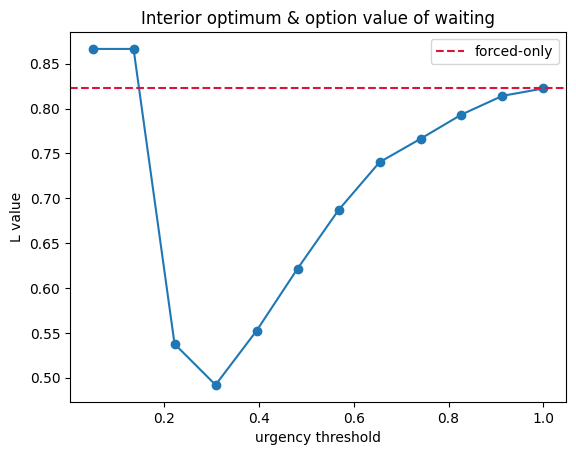

In [4]:
pc = ch05.policy_comparison(replace(p, M=6000))
ths=[r['threshold'] for r in pc['rows']]; vals=[r['L_value'] for r in pc['rows']]
plt.plot(ths, vals, 'o-'); plt.axhline(pc['forced_only'], color='crimson', ls='--', label='forced-only')
plt.xlabel('urgency threshold'); plt.ylabel('L value'); plt.legend(); plt.title('Interior optimum & option value of waiting')
print(f"interior optimum at threshold {pc['interior_optimum']['threshold']:.2f}, option value {pc['option_value_of_waiting']:.4f}")

## 4. Validation checks

In [5]:
v = ch05.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_reservation PASS
V2_mellin PASS
V3_monotone PASS
V4_forced_dominated PASS
V5_reproducible PASS
ALL: True
